In [1]:
!pip -q install monai zarr numcodecs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 106.9 MB/s eta 0:00:0000:0100:01


In [16]:
import os
import gc
import random
import warnings

from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import zarr

from scipy.ndimage import gaussian_filter

from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import random_split

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [17]:
# =====================================================
# Configuration
# =====================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device :", DEVICE)

DATA_DIR = Path(
    "/kaggle/input/competitions/biohub-cell-tracking-during-development/train"
)

CACHE_DIR = Path(
    "/kaggle/working/frame_cache"
)

CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DEPTH = 64
HEIGHT = 256
WIDTH = 256

SIGMA = (1.5,3.0,3.0)

print("Cache Directory :", CACHE_DIR)

Device : cuda
Cache Directory : /kaggle/working/frame_cache


In [18]:
zarr_files = sorted(
    DATA_DIR.glob("*.zarr")
)

geff_files = sorted(
    DATA_DIR.glob("*.geff")
)

print(f"Volumes : {len(zarr_files)}")
print(f"Labels  : {len(geff_files)}")

assert len(zarr_files)==len(geff_files)

Volumes : 199
Labels  : 199


In [20]:
def read_nodes(geff_file):

    gt = zarr.open(
        geff_file,
        mode="r"
    )

    nodes = pd.DataFrame({

        "node_id":np.array(
            gt["nodes"]["ids"]
        ),

        "t":np.array(
            gt["nodes"]["props"]["t"]["values"]
        ),

        "z":np.array(
            gt["nodes"]["props"]["z"]["values"]
        ),

        "y":np.array(
            gt["nodes"]["props"]["y"]["values"]
        ),

        "x":np.array(
            gt["nodes"]["props"]["x"]["values"]
        )

    })

    return nodes

In [21]:
def normalize(image):

    image = image.astype(np.float32)

    p1 = np.percentile(
        image,
        1
    )

    p99 = np.percentile(
        image,
        99.8
    )

    image = np.clip(
        image,
        p1,
        p99
    )

    image = (
        image-p1
    ) / (
        p99-p1+1e-8
    )

    return image

In [22]:
from scipy.ndimage import gaussian_filter

# Heatmap resolution after downsampling
HEAT_HEIGHT = 128
HEAT_WIDTH = 128

HEAT_SIGMA = (1.5, 1.5, 1.5)


def create_heatmap(nodes):

    heatmap = np.zeros(
        (DEPTH, HEAT_HEIGHT, HEAT_WIDTH),
        dtype=np.float32
    )

    # Vectorized coordinate extraction
    coords = nodes[["z", "y", "x"]].to_numpy(dtype=np.int32)

    z = coords[:, 0]
    y = coords[:, 1] // 2
    x = coords[:, 2] // 2

    valid = (
        (z >= 0) & (z < DEPTH) &
        (y >= 0) & (y < HEAT_HEIGHT) &
        (x >= 0) & (x < HEAT_WIDTH)
    )

    heatmap[
        z[valid],
        y[valid],
        x[valid]
    ] = 1.0

    gaussian_filter(
        heatmap,
        sigma=HEAT_SIGMA,
        output=heatmap
    )

    m = heatmap.max()

    if m > 0:
        heatmap /= m

    return heatmap

In [23]:
samples = []

for zarr_file in tqdm(zarr_files):

    geff = zarr_file.with_suffix(".geff")

    nodes = read_nodes(geff)

    embryo = zarr_file.stem

    for t,group in nodes.groupby("t"):

        samples.append({

            "embryo":embryo,

            "file":zarr_file,

            "time":int(t),

            "nodes":group.reset_index(drop=True)

        })

print()

print("Frames :",len(samples))

  0%|          | 0/199 [00:00<?, ?it/s]


Frames : 18933


In [24]:
frame_stats = pd.DataFrame({

    "Embryo":[
        s["embryo"] for s in samples
    ],

    "Time":[
        s["time"] for s in samples
    ],

    "Cells":[
        len(s["nodes"]) for s in samples
    ]

})

display(frame_stats.head())

print()

print("Average Cells / Frame :",frame_stats.Cells.mean())

print("Maximum Cells / Frame :",frame_stats.Cells.max())

print("Minimum Cells / Frame :",frame_stats.Cells.min())

,Embryo,Time,Cells
0,44b6_0113de3b,0,1
1,44b6_0113de3b,1,1
2,44b6_0113de3b,2,1
3,44b6_0113de3b,27,1
4,44b6_0113de3b,28,1



Average Cells / Frame : 7.0415676332329795
Maximum Cells / Frame : 33
Minimum Cells / Frame : 1


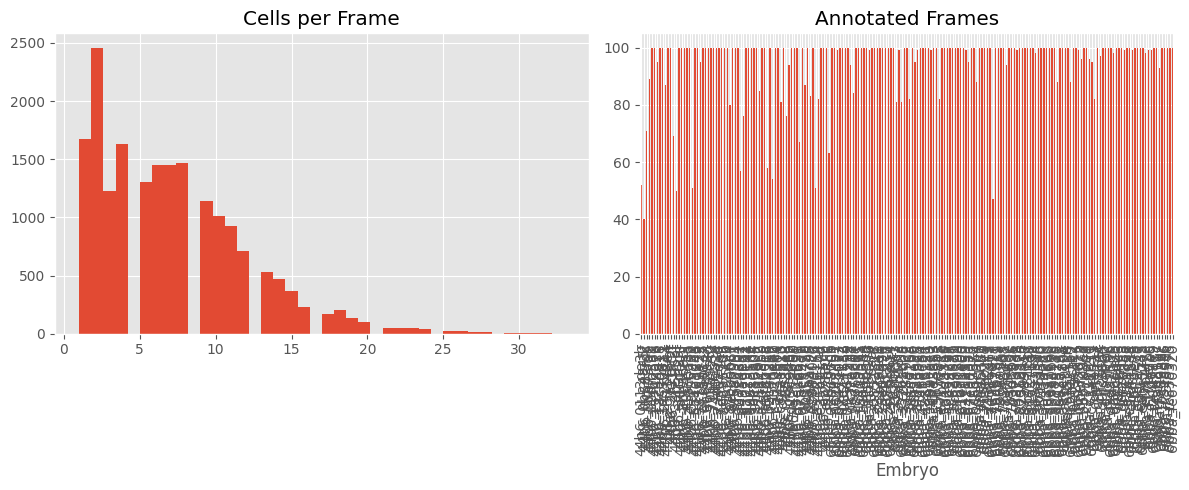

In [25]:
fig,ax = plt.subplots(

    1,

    2,

    figsize=(12,5)

)

frame_stats.Cells.hist(

    bins=40,

    ax=ax[0]

)

ax[0].set_title("Cells per Frame")

frame_stats.groupby(

    "Embryo"

).size().plot.bar(

    ax=ax[1]

)

ax[1].set_title("Annotated Frames")

plt.tight_layout()

plt.show()

In [26]:
# ============================================================
# Create Cache Directory
# ============================================================

CACHE_DIR = Path("/kaggle/working/frame_cache")

CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(CACHE_DIR)

/kaggle/working/frame_cache


In [27]:
from scipy.ndimage import zoom

def downsample_volume(volume):

    return zoom(
        volume,
        (1, 0.5, 0.5),   # Z unchanged, XY halved
        order=1          # bilinear
    ).astype(np.float32)

In [28]:
cache_files = sorted(

    CACHE_DIR.glob("*.npz")

)

print("Embryos Cached :",len(cache_files))

for f in cache_files[:5]:

    print(f.name)

Embryos Cached : 0


In [29]:
# ============================================================
# Group Frames
# ============================================================

from collections import defaultdict

embryos = defaultdict(list)

for sample in samples:

    embryos[
        sample["embryo"]
    ].append(sample)

print(
    "Embryos:",
    len(embryos)
)

Embryos: 199


In [30]:
# ============================================================
# Create Cache
# ============================================================

for embryo, embryo_samples in tqdm(embryos.items()):

    embryo_dir = CACHE_DIR / embryo

    embryo_dir.mkdir(

        exist_ok=True

    )

    image_file = embryo_dir / "images.npy"

    target_file = embryo_dir / "targets.npy"

    time_file = embryo_dir / "times.npy"

    if (

        image_file.exists()

        and

        target_file.exists()

        and

        time_file.exists()

    ):

        continue

    volume = zarr.open(

        embryo_samples[0]["file"],

        mode="r"

    )["0"]

    images = []

    targets = []

    times = []

    for sample in embryo_samples:

        frame = normalize(

            volume[
                sample["time"]
            ]

        )

        heat = create_heatmap(

            sample["nodes"]

        )

        # Downsample ONCE

        frame = downsample_volume(

            frame

        )

        heat = downsample_volume(

            heat

        )

        images.append(

            frame.astype(np.float32)

        )

        targets.append(

            heat.astype(np.float32)

        )

        times.append(

            sample["time"]

        )

    np.save(

        image_file,

        np.stack(images)

    )

    np.save(

        target_file,

        np.stack(targets)

    )

    np.save(

        time_file,

        np.asarray(

            times,

            dtype=np.int32

        )
    )

print()

print("Cache Created")

  0%|          | 0/199 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [31]:
# ============================================================
# Verify Cache
# ============================================================

folders = sorted(

    CACHE_DIR.iterdir()

)

print(

    "Cached Embryos:",

    len(folders)

)

for folder in folders[:3]:

    print(folder.name)

Cached Embryos: 9
44b6_0113de3b
44b6_0b24845f
44b6_0c582fdc


In [32]:
folder = folders[0]

images = np.load(

    folder/"images.npy"

)

targets = np.load(

    folder/"targets.npy"

)

times = np.load(

    folder/"times.npy"

)

print(images.shape)

print(targets.shape)

print(times.shape)

print()

print(images.dtype)

print(targets.dtype)

(52, 64, 128, 128)
(52, 64, 128, 128)
(52,)

float32
float32


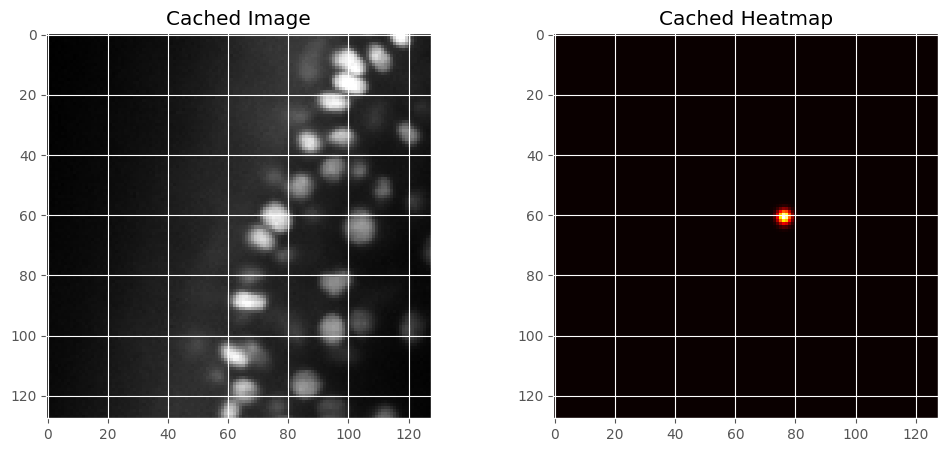

In [33]:
idx = np.random.randint(

    len(images)

)

image = images[idx]

target = targets[idx]

best = np.argmax(

    target.max(

        axis=(1,2)

    )

)

fig,ax = plt.subplots(

    1,

    2,

    figsize=(12,5)

)

ax[0].imshow(

    image[best],

    cmap="gray"

)

ax[0].set_title(

    "Cached Image"

)

ax[1].imshow(

    target[best],

    cmap="hot"

)

ax[1].set_title(

    "Cached Heatmap"

)

plt.show()

In [34]:
import time

folder = folders[0]

start = time.time()

images = np.load(

    folder/"images.npy",

    mmap_mode="r"

)

targets = np.load(

    folder/"targets.npy",

    mmap_mode="r"

)

times = np.load(

    folder/"times.npy"

)

print(

    "Load Time:",

    time.time()-start,

    "seconds"

)

Load Time: 0.002747058868408203 seconds
